<Axes: >

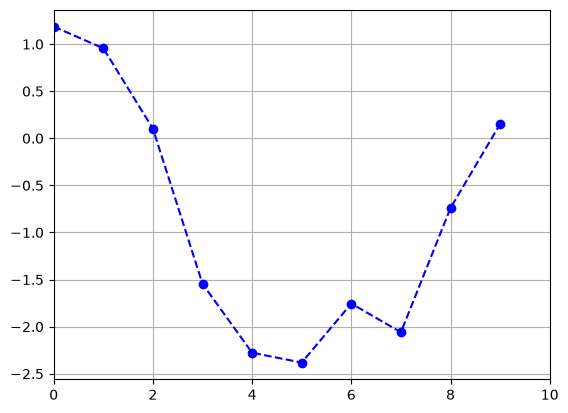

In [9]:
import pandas as pd
import numpy as np

# 9.2 Plotting with pandas and seaborn
## Line Plots
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot(use_index=False, label="Series.plot", grid=True, xlim=[0, 10], style='bo--')


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

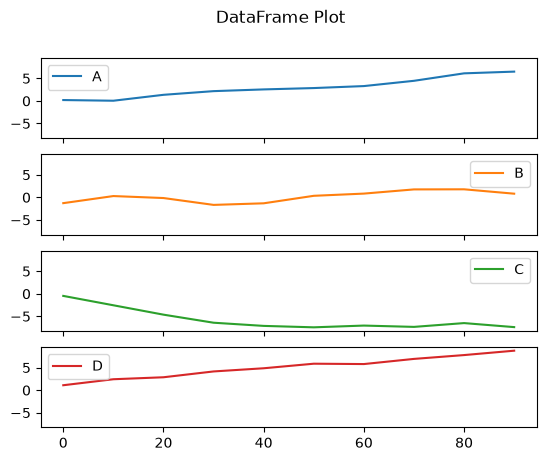

In [14]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index = np.arange(0,100,10))

df.plot(subplots=True, sharex=True, sharey=True, title='DataFrame Plot')

<Axes: >

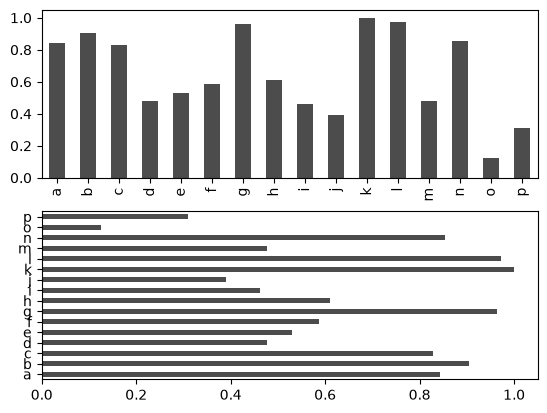

In [17]:
import matplotlib.pyplot as plt

## Bar Plots
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='k', alpha=0.7)
data.plot.barh(ax=axes[1], color='k', alpha=0.7)

<Axes: >

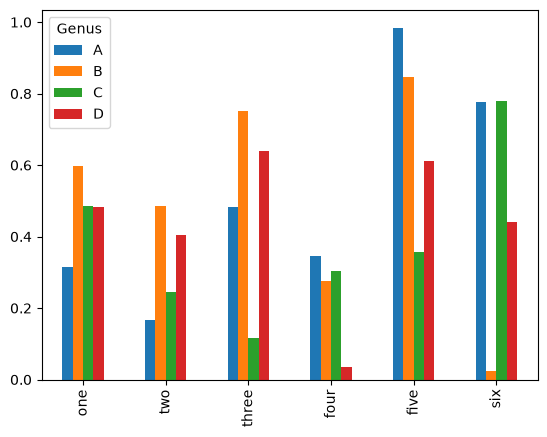

In [28]:
df = pd.DataFrame(np.random.rand(6, 4),
                  index=['one', 'two', 'three', 'four', 'five', 'six'], 
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df.plot.bar()

<Axes: >

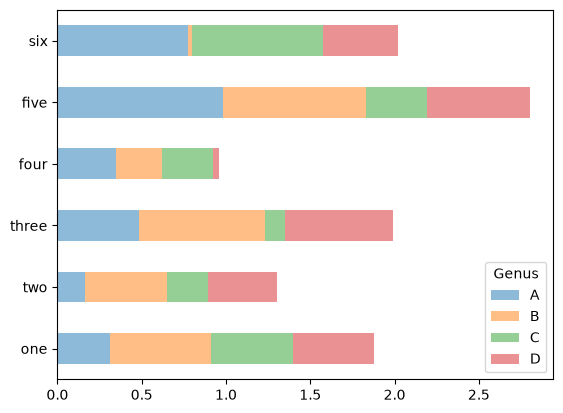

In [30]:
df.plot.barh(stacked=True, alpha=0.5)

In [32]:
tips = pd.read_csv('examples/tips.csv')
party_counts = pd.crosstab(tips['day'], tips['size'])
party_counts = party_counts.loc[:, 2:5]
party_counts

size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


C:\Users\HP\AppData\Local\Temp\ipykernel_20908\1494835728.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  party_pcts = party_counts.div(party_counts.sum(1), axis=0)


<Axes: xlabel='day'>

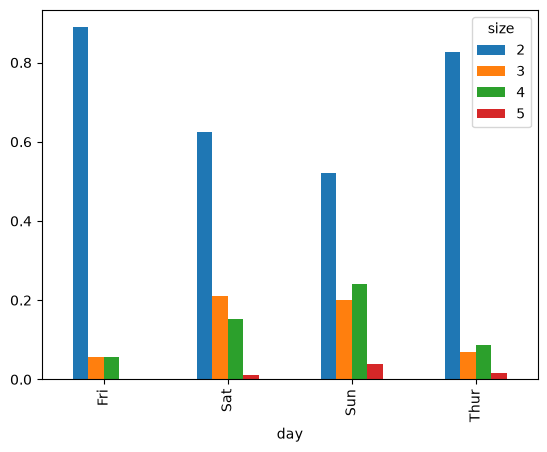

In [34]:
party_pcts = party_counts.div(party_counts.sum(1), axis=0)
party_pcts.plot.bar()

<Axes: xlabel='tip_pct', ylabel='day'>

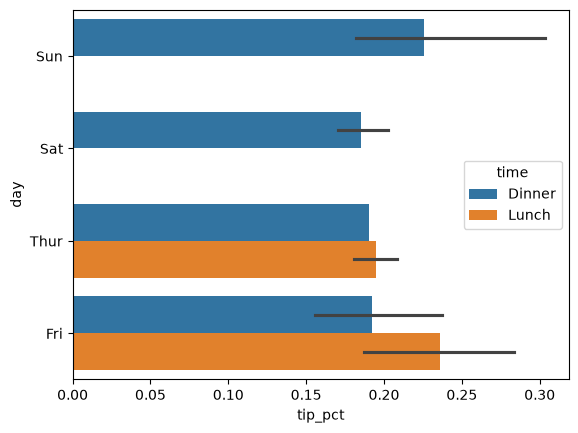

In [38]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips.head()
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

<Axes: ylabel='Frequency'>

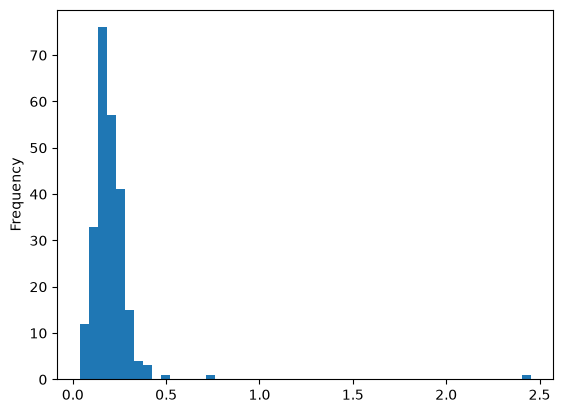

In [40]:
# Histograms and Density Plots
tips['tip_pct'].plot.hist(bins=50)

<Axes: ylabel='Density'>

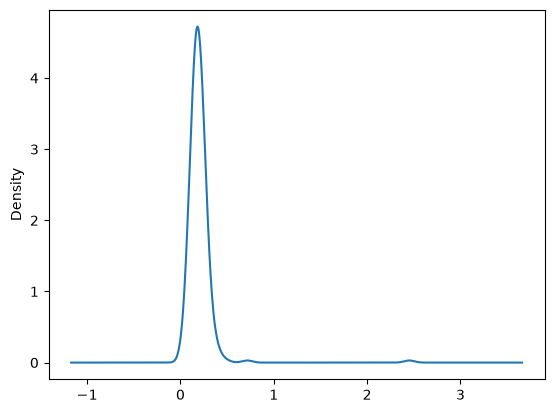

In [42]:
tips['tip_pct'].plot.density()

C:\Users\HP\AppData\Local\Temp\ipykernel_20908\145139174.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(values, bins=100, color='k')


<Axes: ylabel='Density'>

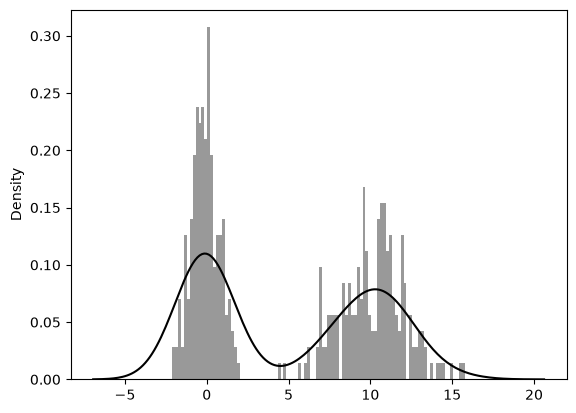

In [49]:
comp1 = np.random.normal(0, 1, size=200)
comp2 = np.random.normal(10, 2, size=200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.distplot(values, bins=100, color='k')


Text(0.5, 1.0, 'Changes in log m1 versus log unemp')

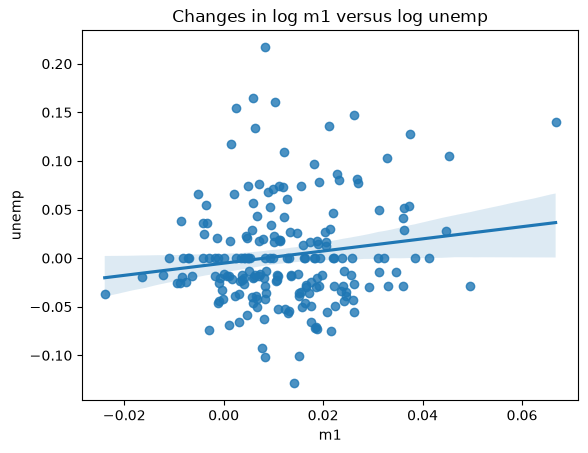

In [55]:
# Scatter or Point Plots
macro = pd.read_csv('examples/macrodata.csv')
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
sns.regplot(x='m1', y='unemp', data=trans_data)
plt.title('Changes in log %s versus log %s' % ('m1', 'unemp'))

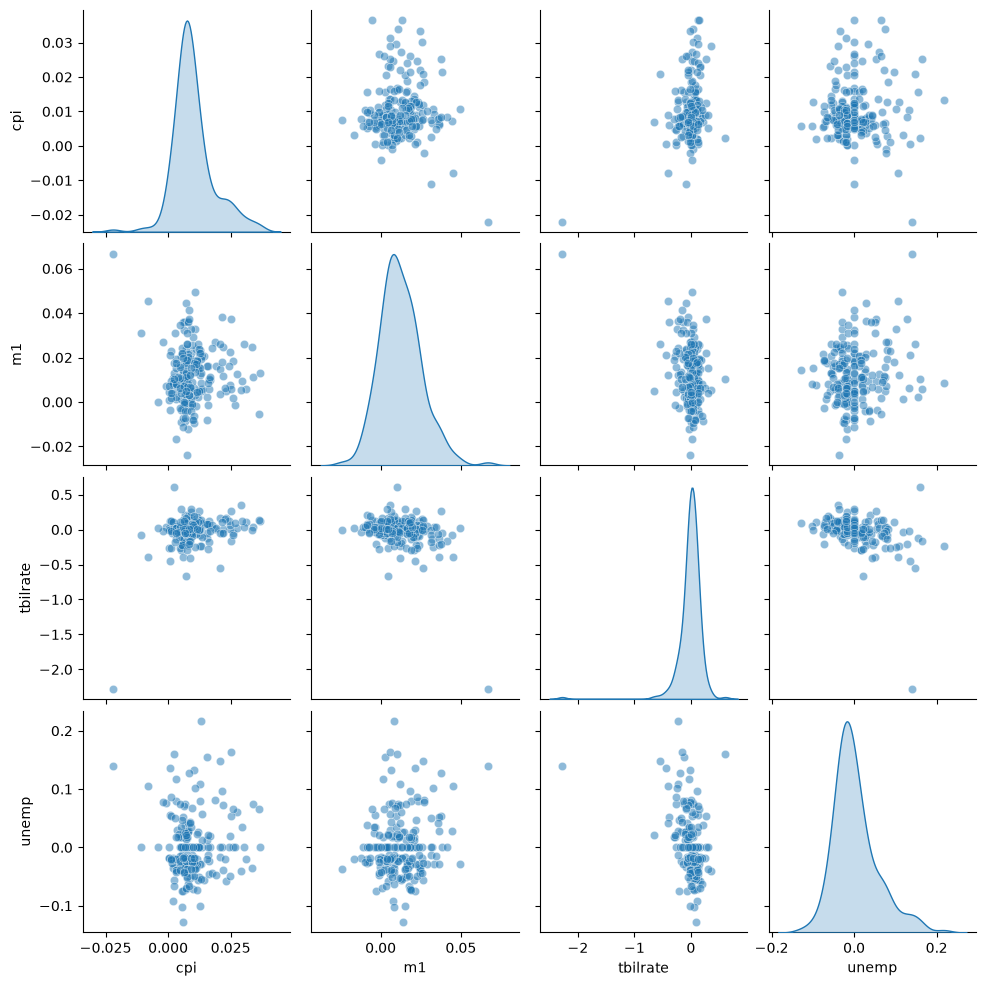

In [58]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha': 0.5})

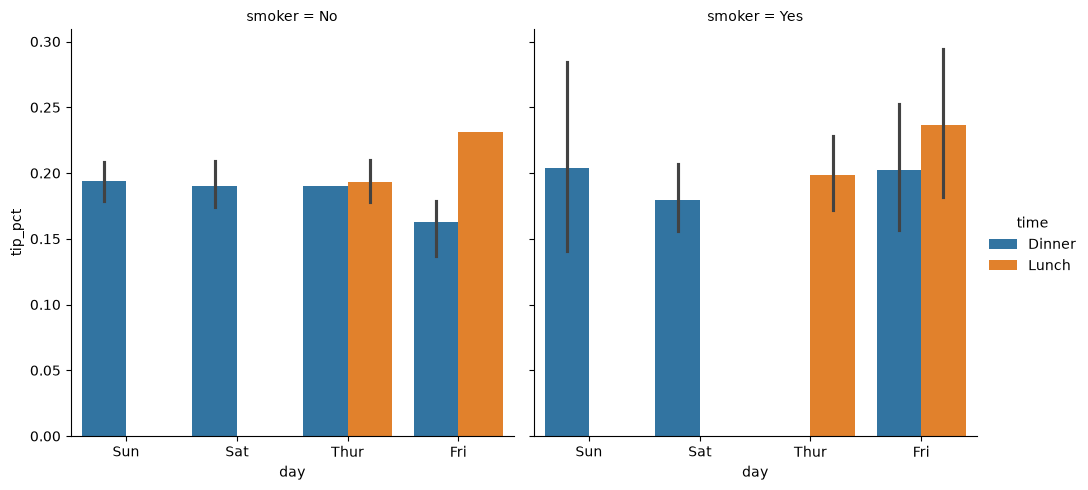

In [64]:
# Facet Grids and Categorical Data
sns.catplot(x='day', y='tip_pct', hue='time', col='smoker',
            kind='bar', data=tips[tips.tip_pct < 1])

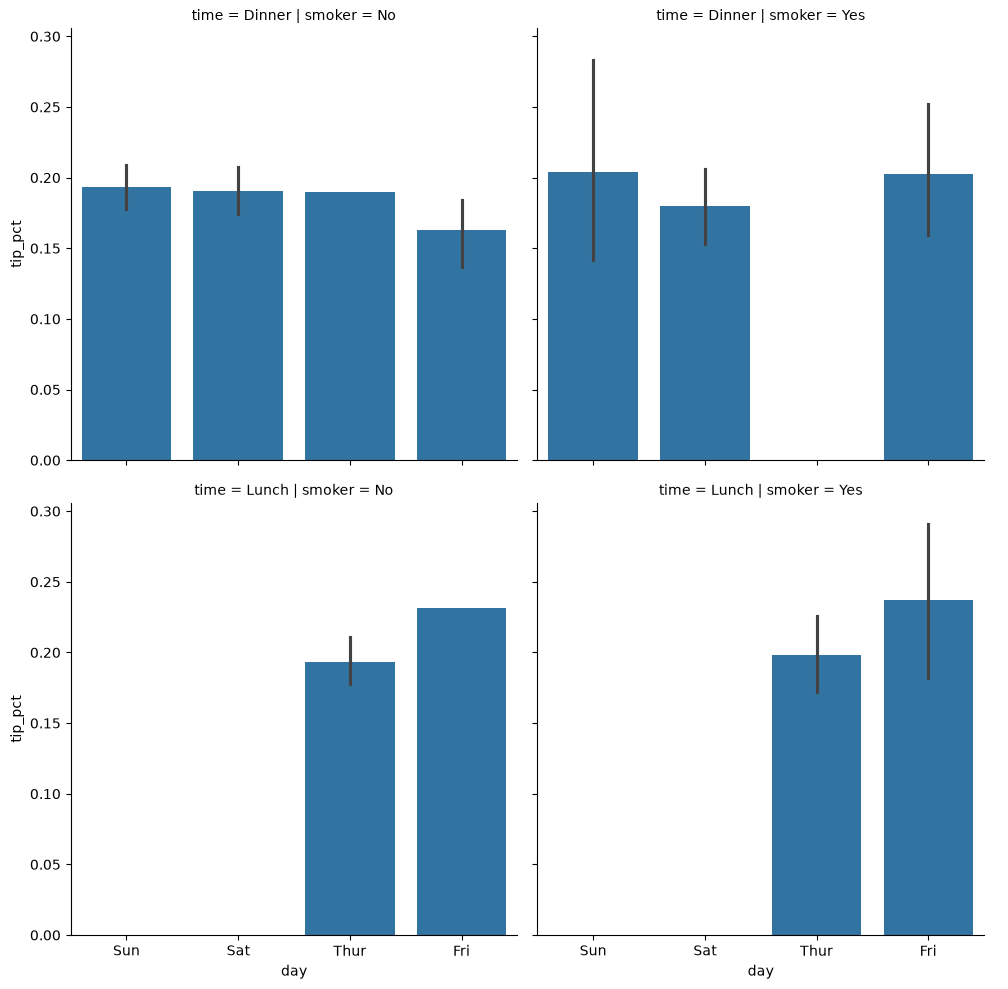

In [69]:
sns.catplot(x='day', y='tip_pct', row='time', col='smoker',
            kind='bar', data=tips[tips.tip_pct < 1])

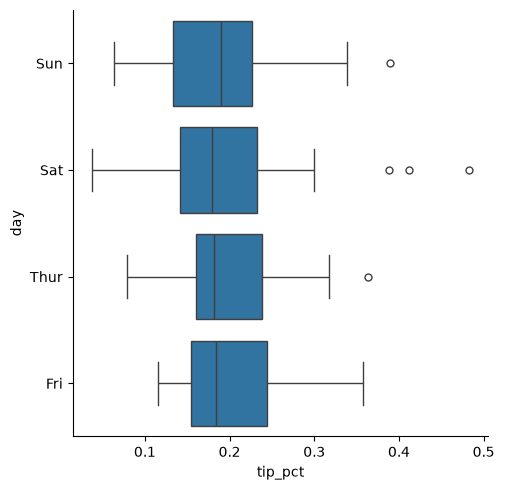

In [70]:
sns.catplot(x='tip_pct', y='day', kind='box', data=tips[tips.tip_pct < 0.5])